<a href="https://colab.research.google.com/github/NoahSlaa/bioinfomatician/blob/main/p_aeruginosa_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import files
uploaded=files.upload()

Saving archive (3).zip to archive (3).zip


In [4]:
!unzip "archive (3).zip"

Archive:  archive (3).zip
  inflating: pseudomonas_aeruginosa.csv  


<Figure size 900x2500 with 0 Axes>

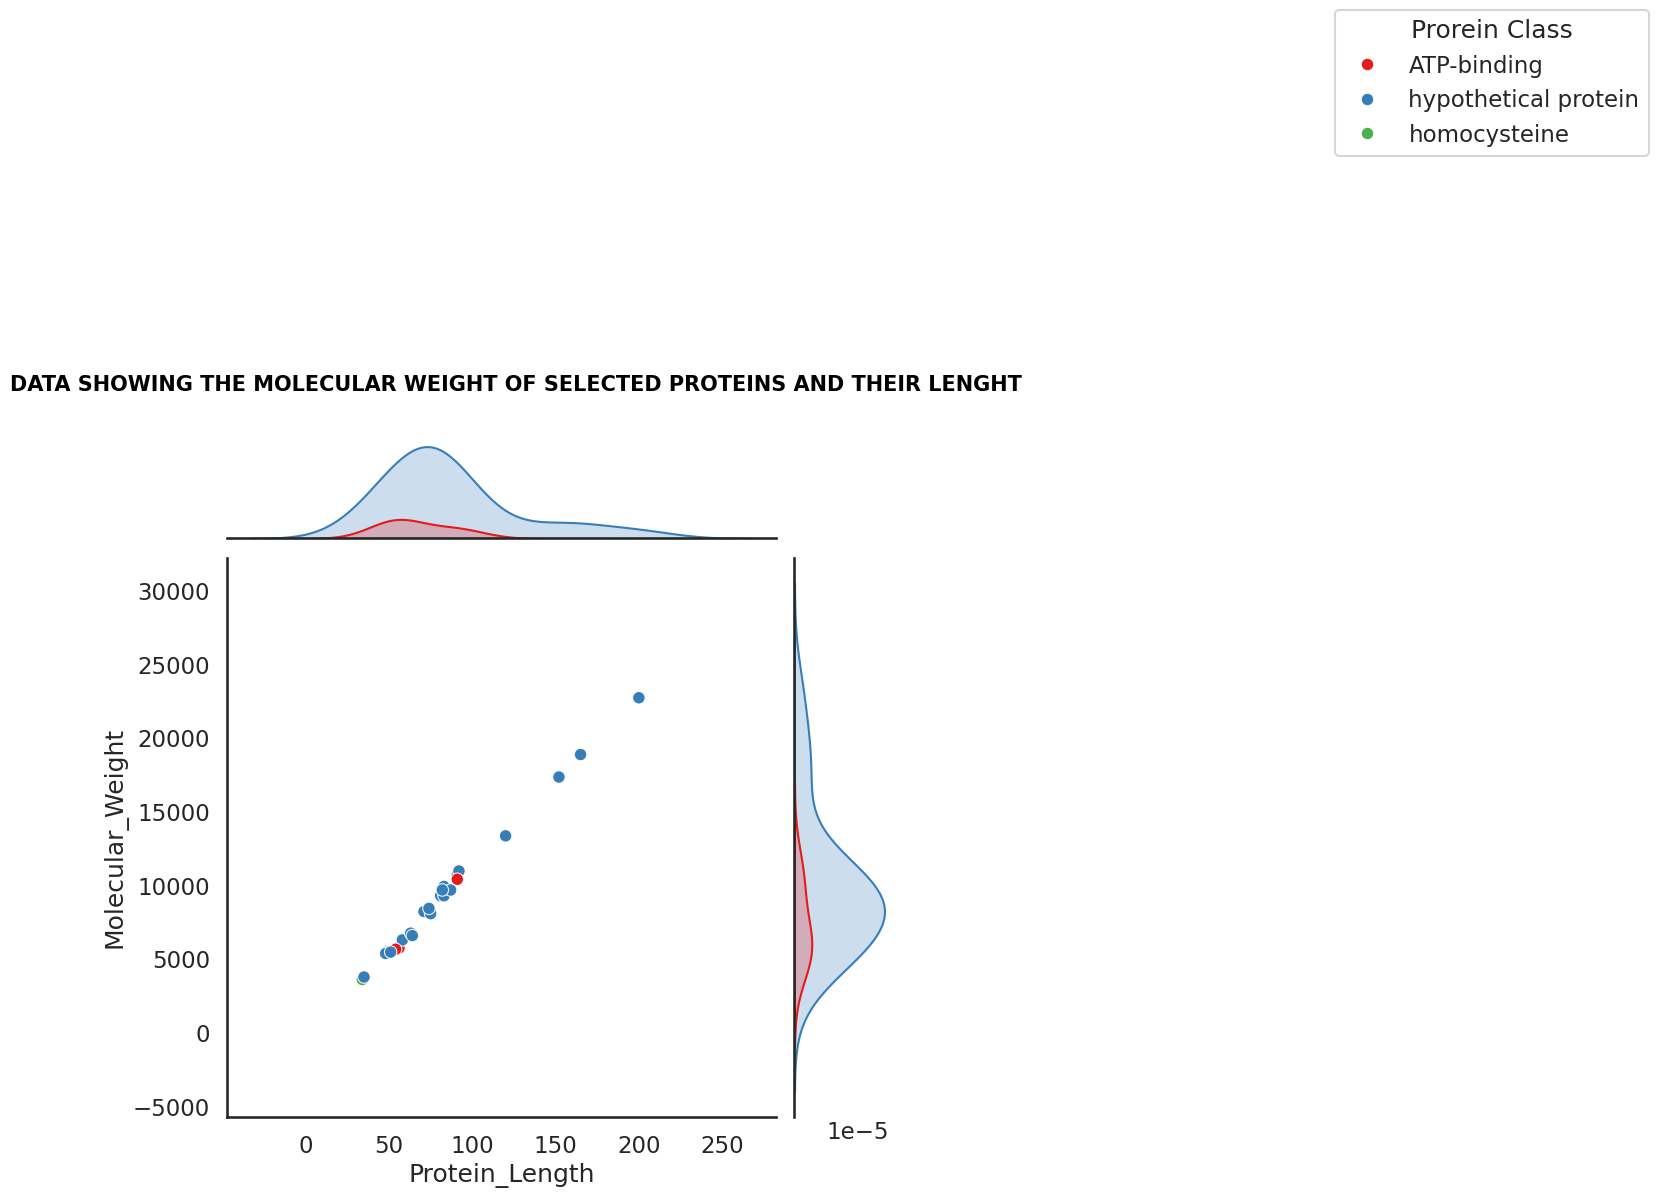

In [62]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv( "pseudomonas_aeruginosa.csv")
key="ATP-binding|hypothetical protein|homocysteine|pillin"

clean=df[df["Name"].str.contains(key,case=False,na=False)][["Name","Molecular_Weight","Protein_Length"]]
clean['Molecular_Weight']=pd.to_numeric(clean['Molecular_Weight'],errors="coerce")
clean['Protein_Length']=pd.to_numeric(clean['Protein_Length'],errors="coerce")
clean=clean.dropna()

final=clean.head(20).reset_index(drop=True)
#Data visualization
def classify_proteins(name):
  name_lower=str(name).lower()
  if 'atp' in name_lower:
    return 'ATP-binding'
  elif 'hypothetical' in name_lower:
    return 'hypothetical protein'
  elif 'homocysteine' in name_lower:
    return 'homocysteine'
  elif 'pillin' in name_lower:
    return 'pillin'
  else:
    return 'other proteins'
plt.figure(figsize=(9,25))
g.ax_joint.grid(True,linestyle="--",alpha=0.6)
g.set_axis_labels("Protein_Length","Molecular_Weight",fontweight="bold",fontsize=14,)

clean["category"]=clean["Name"].apply(classify_proteins)
sns.set_theme(style="white",context="talk")
g=sns.jointplot(data=clean,x="Protein_Length",y='Molecular_Weight',hue='category',palette="Set1",alpha=1,height=8)

g.fig.suptitle("DATA SHOWING THE MOLECULAR WEIGHT OF SELECTED PROTEINS AND THEIR LENGHT",y=1.05,fontsize=15,fontweight="bold",color="black")
sns.move_legend(g.ax_joint, "upper left", bbox_to_anchor=(2, 2),title="Prorein Class")
plt.savefig("p_aeruginosa_plot.png",dpi=300,bbox_inches="tight")
plt.show()


